# Silco Jupyter Smoke Test

This notebook exercises plugin discovery, the IPython rich representation plugin, SVG rendering, and the core graphics backend.

In [2]:
from silco import diagram, kernel

discovered = kernel.discover()
print('Discovered:', [(p.category, p.name) for p in discovered])
print('Renderers:', kernel.names('renderers'))
print('Layouts:', kernel.names('layouts'))
print('Presenters:', kernel.names('presenters'))

Discovered: []
Renderers: ('svg', 'mermaid', 'pdf')
Layouts: ('dag', 'grid')
Presenters: ('ipython',)


In [3]:
%reload_ext silco.plugins.ipython

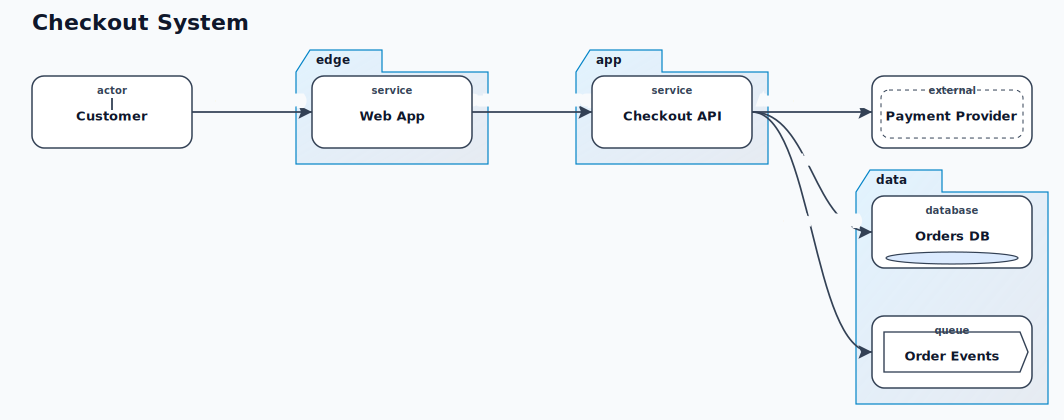

In [4]:
checkout = (
    diagram('Checkout System')
    .node('user', 'Customer', kind='actor')
    .node('web', 'Web App', kind='service', group='edge')
    .node('api', 'Checkout API', kind='service', group='app')
    .node('payments', 'Payment Provider', kind='external')
    .node('orders', 'Orders DB', kind='database', group='data')
    .node('events', 'Order Events', kind='queue', group='data')
    .connect('user', 'web', 'Browses', protocol='HTTPS')
    .connect('web', 'api', 'Submit cart', protocol='HTTPS')
    .connect('api', 'payments', 'Authorize', protocol='REST')
    .connect('api', 'orders', 'Persist', protocol='SQL')
    .connect('api', 'events', 'Publish', protocol='AMQP')
)

checkout

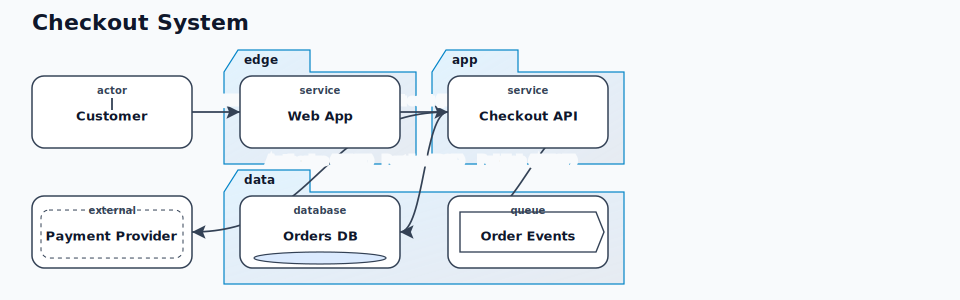

In [5]:
from IPython.display import SVG, display

display(SVG(checkout.to_svg(layout='grid')))

In [6]:
from core.renderers.base.graphics import Canvas

canvas = Canvas(180, 80, {'role': 'img'})
canvas.rect(10, 10, 160, 60, rx=12, fill='#e2e8f0')
canvas.text('Core graphics', 90, 45, class_='silco-label')
print(canvas.to_svg())


<svg xmlns="http://www.w3.org/2000/svg" width="180" height="80" viewBox="0 0 180 80" role="img">
<rect x="10" y="10" width="160" height="60" rx="12" fill="#e2e8f0"/>
<text x="90" y="45" class="silco-label">Core graphics</text>
</svg>


In [7]:
assert 'svg' in kernel.names('renderers')
assert 'dag' in kernel.names('layouts')
assert 'ipython' in kernel.names('presenters')
svg = checkout.to_svg()
assert '<svg' in svg
assert 'silco-node' in svg
print('Silco notebook smoke test passed.')


Silco notebook smoke test passed.
